In [1]:
from scripts.visual_degradation import add_awgn
from scripts.data_visualization import load_sample,overlay_masks,overlay_boxes
from scripts.converters import convert_boxes_to_xywh
from scripts.model_helper import load_model, run_sam3
from matplotlib import pyplot as plt

import torch
from PIL import Image
import cv2
img_name ='sa_11177073'

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model,processor = load_model(device)

Using device: cuda


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

In [3]:
img, _ = load_sample(img_name)
noisy_img_1 = add_awgn(img, sigma=10)
noisy_img_2 = add_awgn(img, sigma=25)
noisy_img_3 = add_awgn(img, sigma=50)


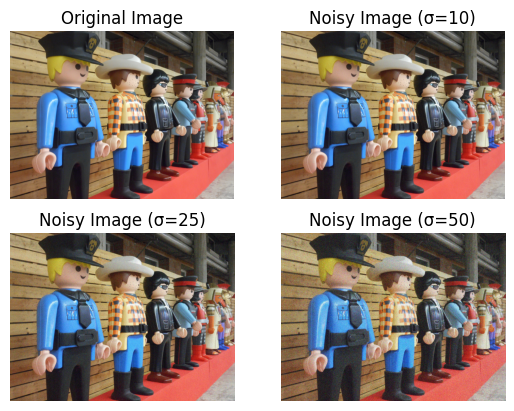

In [4]:
fig, axs = plt.subplots(2, 2)
axs[0, 0].imshow(img)
axs[0, 0].set_title('Original Image')
axs[0, 0].axis('off')
axs[0, 1].imshow(noisy_img_1)
axs[0, 1].set_title('Noisy Image (σ=10)')
axs[0, 1].axis('off')
axs[1, 0].imshow(noisy_img_2)
axs[1, 0].set_title('Noisy Image (σ=25)')
axs[1, 0].axis('off')
axs[1, 1].imshow(noisy_img_3)
axs[1, 1].set_title('Noisy Image (σ=50)')
axs[1, 1].axis('off')
plt.show()

In [6]:
results = run_sam3(model,processor,img,device)

masks = results["masks"]
boxes = convert_boxes_to_xywh(results["boxes"].cpu().numpy())

img = overlay_masks(img, masks)
img = overlay_boxes(img, boxes, color=(255, 0, 0), label="predicted")

print(len(results["masks"]))

9


In [7]:
results = run_sam3(model,processor,noisy_img_1,device)

masks = results["masks"]
boxes = convert_boxes_to_xywh(results["boxes"].cpu().numpy())

noisy_img_1 = overlay_masks(noisy_img_1, masks)
noisy_img_1 = overlay_boxes(noisy_img_1, boxes, color=(255, 0, 0), label="predicted")
print(len(results["masks"]))

8


In [8]:
results = run_sam3(model,processor,noisy_img_2,device)

masks = results["masks"]
boxes = convert_boxes_to_xywh(results["boxes"].cpu().numpy())

noisy_img_2 = overlay_masks(noisy_img_2, masks)
noisy_img_2 = overlay_boxes(noisy_img_2, boxes, color=(255, 0, 0), label="predicted")
print(len(results["masks"]))

9


In [9]:
results = run_sam3(model,processor,noisy_img_3,device)

masks = results["masks"]
boxes = convert_boxes_to_xywh(results["boxes"].cpu().numpy())

noisy_img_3 = overlay_masks(noisy_img_3, masks)
noisy_img_3 = overlay_boxes(noisy_img_3, boxes, color=(255, 0, 0), label="predicted")
print(len(results["masks"]))

8


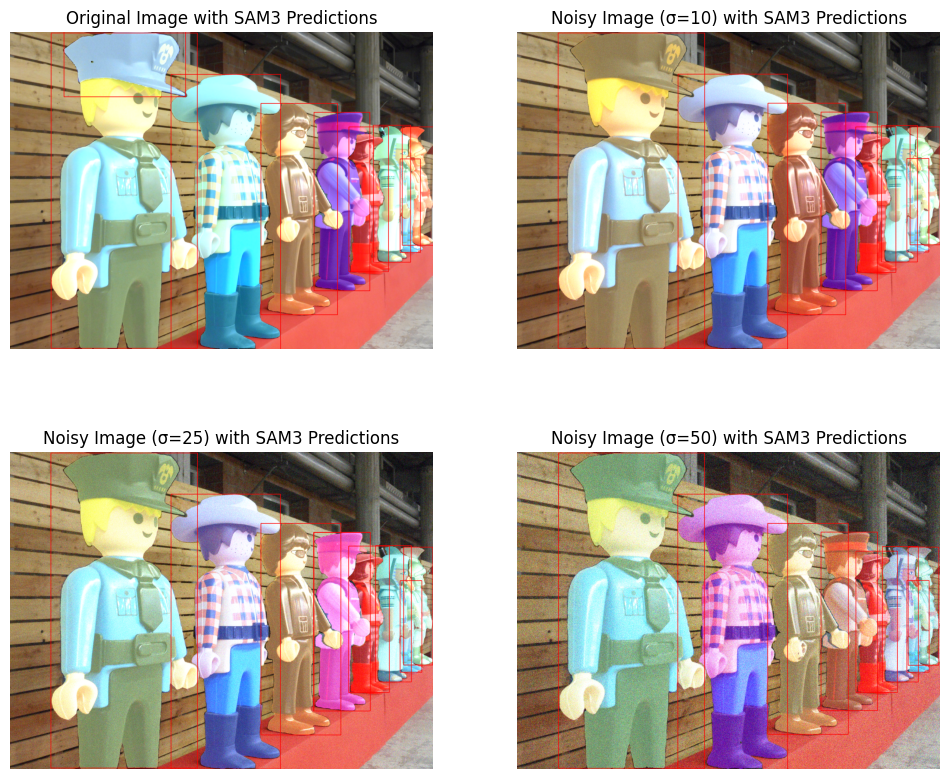

In [10]:
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.imshow(img)
plt.title('Original Image with SAM3 Predictions')
plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(noisy_img_1)
plt.title('Noisy Image (σ=10) with SAM3 Predictions')
plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(noisy_img_2)
plt.title('Noisy Image (σ=25) with SAM3 Predictions')
plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(noisy_img_3)
plt.title('Noisy Image (σ=50) with SAM3 Predictions')
plt.axis('off')
plt.show()